In [4]:
import pandas as pd

In [5]:
movies = pd.read_csv('movie.csv')

In [6]:
movies.shape

(27278, 3)

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings = pd.read_csv('rating.csv')

In [9]:
ratings.shape

(20000263, 4)

In [10]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [11]:
tags = pd.read_csv('tag.csv')

In [12]:
tags.shape

(465564, 4)

In [13]:
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [14]:
print(movies.columns) 
print(ratings.columns)
print(tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')


In [15]:
del ratings['timestamp']
del tags['timestamp']

In [16]:
print(movies.columns)
print(ratings.columns)
print(tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating'], dtype='object')
Index(['userId', 'movieId', 'tag'], dtype='object')


Data Structures:

In [21]:
row_0 = tags.iloc[0]
type(row_0)
# iloc: integer location
# loc: label location
# iloc[0] -> 0th row
# loc[0] -> row with index 0 (which may not be the first row
# here row_0 refers to the first row of the tags dataframe, which has an index of 0, so both iloc[0] and loc[0] would return the same row in this case. However, if the dataframe had a different index (e.g., starting from 1 or using non-integer labels), then iloc[0] would still return the first row, while loc[0] would look for a row with index label 0, which may not exist.

pandas.core.series.Series

In [22]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [23]:
print(row_0)

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object


In [24]:
print(row_0['userId'])

18


In [25]:
print(row_0['tag'])

Mark Waters


In [ ]:
'rating' in row_0
# 'rating' is not a column in the tags dataframe, so it will not be found in row_0, which is a Series object representing a single row of the tags dataframe.

False

In [27]:
'movieId' in row_0
# 'movieId' is a column in the tags dataframe, so it will be found in row_0, which is a Series object representing a single row of the tags dataframe.

True

In [28]:
row_0.name
# The name attribute of a Series object in pandas represents the label of the row or column that the Series represents. In this case, since row_0 is a Series object representing a single row of the tags dataframe, its name attribute will be the index label of that row, which is 0 in this case.

0

In [29]:
row_0 = row_0.rename('first_row') 
row_0.name
# The rename method is used to change the name of a Series object. In this case, we are renaming row_0 to 'first_row'. After renaming, the name attribute of row_0 will be 'first_row' instead of 0.

'first_row'

In [30]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

Data Frames:

In [31]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [32]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [34]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [35]:
tags.iloc[[0,8,15]]
# iloc is used to select rows based on their integer position in the dataframe. In this case, we are selecting the rows at positions 0, 8, and 15 from the tags dataframe. The double square brackets [[ ]] are used to indicate that we want to select multiple rows and return a DataFrame instead of a Series.

,userId,movieId,tag
0,18,4141,Mark Waters
8,65,1391,mars
15,65,2662,mars


Descriptive Statistics:

In [38]:
ratings['rating'].describe()
# descibe() method is used to generate descriptive statistics of a Series or DataFrame. In this case, we are calling describe() on the 'rating' column of the ratings dataframe, which will return various statistics such as count, mean, standard deviation, minimum, 25th percentile, median (50th percentile), 75th percentile, and maximum of the ratings.

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [39]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [40]:
print(ratings['rating'].mean())

3.5255285642993797


In [41]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [42]:
print(ratings['rating'].min())

0.5


In [43]:
print(ratings['rating'].max())

5.0


In [44]:
print(ratings['rating'].std())

1.0519889192942424


In [45]:
print(ratings['rating'].mode())

0    4.0
Name: rating, dtype: float64


In [46]:
ratings.corr()
# The corr() method is used to compute pairwise correlation of columns in a DataFrame. In this case, we are calling corr() on the ratings dataframe, which will compute the correlation between the 'userId', 'movieId', and 'rating' columns. The resulting correlation matrix will show how strongly each pair of columns is correlated with each other, with values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation).

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [48]:
filter1 = ratings['rating'] > 10
print(filter1)
filter1.any()
# The any() method is used to check if any element in a Series or DataFrame is True. In this case, we are applying the any() method to the filter1 Series, which contains boolean values indicating whether each rating is greater than 10. If any of the ratings in the ratings dataframe are greater than 10, then filter1.any() will return True; otherwise, it will return False.

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool


False

In [49]:
filter2 = ratings['rating'] > 0
print(filter2.all())

True


Data Cleaning: Handling Missing Data

In [52]:
movies.shape

(27278, 3)

In [53]:
print(movies.isnull().any().any())

False


In [54]:
ratings.shape

(20000263, 3)

In [55]:
print(ratings.isnull().any().any())

False


In [57]:
tags.shape

(465564, 3)

In [58]:
print(tags.isnull().any().any())

True


In [59]:
tags = tags.dropna()
# The dropna() method is used to remove missing values (NaN) from a DataFrame. In this case, we are calling dropna() on the tags dataframe, which will remove any rows that contain NaN values in any of the columns. After this operation, the tags dataframe will only contain rows with complete data, and any rows with missing values will be dropped.

In [60]:
tags.shape

(465548, 3)

Data Visualizations:

In [61]:
import matplotlib.pyplot as plt

In [62]:
%matplotlib inline

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

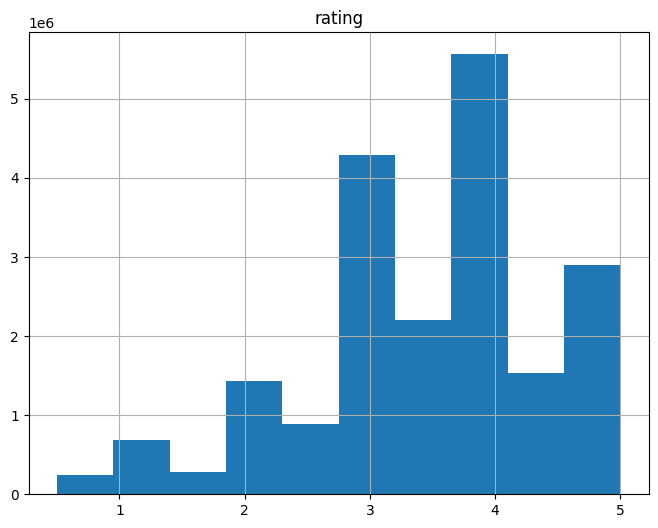

In [63]:
ratings.hist(column='rating', figsize=(8,6))

<Axes: >

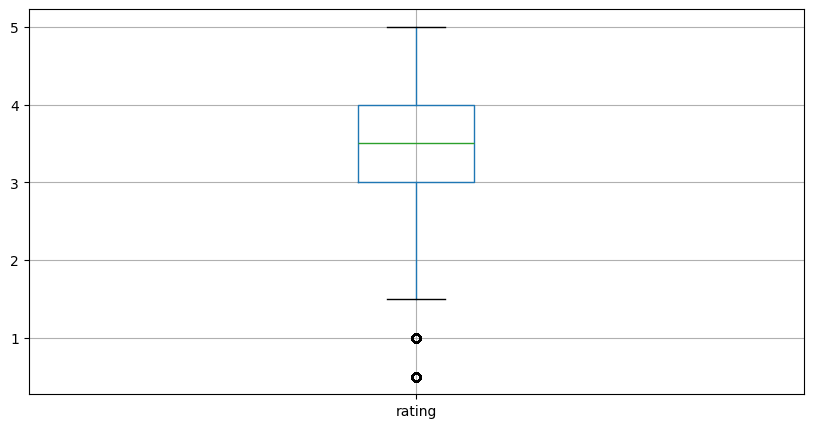

In [64]:
ratings.boxplot(column='rating',figsize=(10,5))

Slicing Out Columns:

In [65]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [66]:
movies[['title','genres']].head() 

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [68]:
ratings[-10:]
# This code is used to display the last 10 rows of the ratings dataframe. The negative index -10 indicates that we want to start from the 10th last row and include all rows until the end of the dataframe. This can be useful for quickly checking the most recent entries in the ratings dataframe.

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [70]:
tags_count = tags['tag'].value_counts()
tags_count[-10:]
# value_counts() method is used to count the occurrences of each unique value in a Series. In this case, we are calling value_counts() on the 'tag' column of the tags dataframe, which will return a Series containing the count of each unique tag. By using [-10:], we are selecting the last 10 entries from the resulting Series, which will show us the 10 least common tags in the tags dataframe.

tag
missing child                    1
Ron Moore                        1
Citizen Kane                     1
mullet                           1
biker gang                       1
Paul Adelstein                   1
the wig                          1
killer fish                      1
genetically modified monsters    1
topless scene                    1
Name: count, dtype: int64

<Axes: xlabel='tag'>

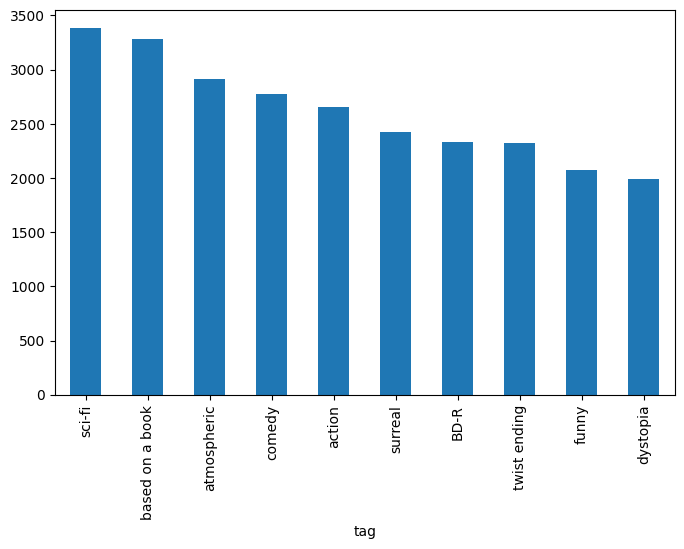

In [71]:
tags_count[:10].plot(kind='bar', figsize=(8,5))